In [ ]:
#Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [ ]:
#Import the dataset
data = pd.read_csv('/content/ice_cream_selling_data.csv')
data

,Temperature (C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [ ]:
data.describe() #Get statistical analytics

,Temperature (C),Ice Cream Sales (units)
count,49.000000,49.000000
mean,0.271755,15.905308
std,2.697672,12.264682
min,-4.662263,0.328626
25%,-2.111870,4.857988
50%,0.688781,12.615181
75%,2.784836,25.142082
max,4.899032,41.842986


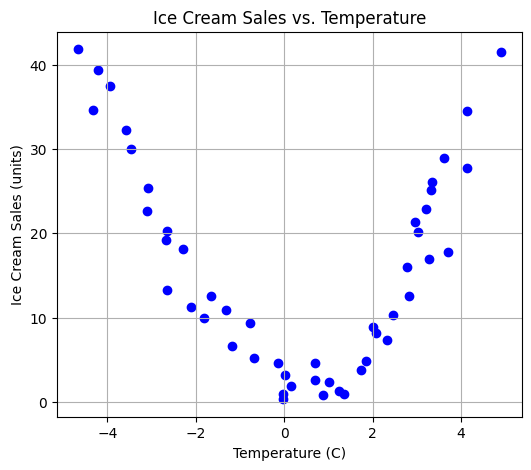

In [ ]:
#Plot a scatter plot for the dataset
plt.figure(figsize=(6, 5))
plt.scatter(data['Temperature (C)'], data['Ice Cream Sales (units)'], color='blue')
plt.title('Ice Cream Sales vs. Temperature')
plt.xlabel('Temperature (C)')
plt.ylabel('Ice Cream Sales (units)')
plt.grid(True)
plt.show()

In [ ]:
#Define the features and target variables
X = data['Temperature (C)'].values.reshape(-1, 1)
y = data['Ice Cream Sales (units)'].values
y.shape

(49,)

In [ ]:
#Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Generating polynomial features
degree= 2
poly_features = PolynomialFeatures(degree=degree)
X_train_poly = poly_features.fit_transform(X_train)
X_test_poly = poly_features.fit_transform(X_test)
X_train_poly.shape
X_test_poly.shape

(10, 3)

In [ ]:
#Perform regression on the dataset
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()

#Fit the Linear Regression model to the polynomial training features
lin_reg.fit(X_train_poly, y_train)

LinearRegression()

In [ ]:
# Make predictions on the polynomial test features
y_pred = lin_reg.predict(X_test_poly)
y_pred

array([10.24499852, 25.82807714, 31.8241041 , 24.61704204,  4.43380256,
        4.00785672,  3.58277492,  3.17865087,  7.86990452,  2.91591369])

In [ ]:
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
df

,Actual,Predicted
0,10.012868,10.244999
1,17.843957,25.828077
2,27.698383,31.824104
3,28.912188,24.617042
4,9.392969,4.433803
5,2.313806,4.007857
6,0.789974,3.582775
7,4.625689,3.178651
8,4.857988,7.869905
9,4.673643,2.915914


In [ ]:
X_poly = poly_features.transform(X)
y_full_pred = lin_reg.predict(X_poly)

# Combine actual values and full predictions into a DataFrame
df_all_predictions = pd.DataFrame({'Actual Ice Cream Sales': y, 'Predicted Ice Cream Sales': y_full_pred})

# Display the DataFrame
df_all_predictions

,Actual Ice Cream Sales,Predicted Ice Cream Sales
0,41.842986,46.740980
1,34.661120,40.687769
2,39.383001,38.977755
3,37.539845,34.752730
4,32.284531,29.262157
5,30.001138,27.558252
6,22.635401,23.046878
7,25.365022,22.713361
8,19.226970,18.022176
9,20.279679,17.806890


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = lin_reg.predict(X_test_poly)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 14.878796425342818
R-squared: 0.8430551373706655


In [ ]:
unseen_data = np.arange(-5, 5, 0.5).reshape(-1, 1) # Generate a range of unseen temperature values
unseen_data_poly = poly_features.transform(unseen_data) # Transform these unseen temperatures into polynomial features
unseen_predictions = lin_reg.predict(unseen_data_poly)# Predict ice cream sales for the unseen data
unseen_df = pd.DataFrame({
    'Unseen Temperature (C)': unseen_data.flatten(),
    'Predicted Ice Cream Sales (units)': unseen_predictions
})

print("Predictions on Unseen Data:")
print(unseen_df)

Predictions on Unseen Data:
    Unseen Temperature (C)  Predicted Ice Cream Sales (units)
0                     -5.0                          53.086683
1                     -4.5                          43.844080
2                     -4.0                          35.537203
3                     -3.5                          28.166051
4                     -3.0                          21.730625
5                     -2.5                          16.230924
6                     -2.0                          11.666949
7                     -1.5                           8.038700
8                     -1.0                           5.346176
9                     -0.5                           3.589378
10                     0.0                           2.768306
11                     0.5                           2.882959
12                     1.0                           3.933338
13                     1.5                           5.919442
14                     2.0                

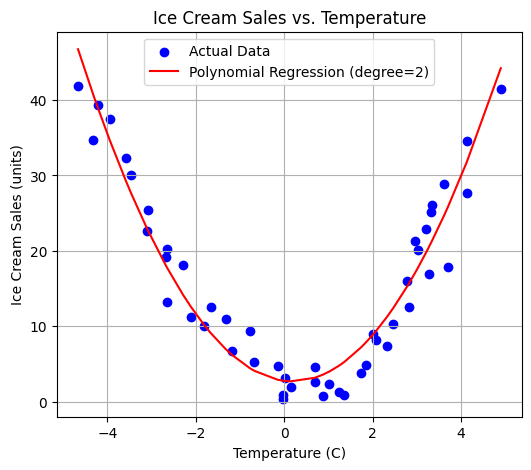

In [ ]:


plt.figure(figsize=(6, 5))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_full_pred, color='red', label=f'Polynomial Regression (degree={degree})')
plt.title('Ice Cream Sales vs. Temperature')
plt.xlabel('Temperature (C)')
plt.ylabel('Ice Cream Sales (units)')
plt.grid(True)
plt.legend()
plt.show()